# Task 3: Customer Churn Prediction (Bank Customers)
---


## 1. Introduction & Problem Statement

Customer churn the phenomenon where customers stop doing business with a company is a major concern in the banking industry. Acquiring new customers is far more expensive than retaining existing ones. Therefore, identifying at-risk customers early allows banks to take proactive retention steps.

**Objective:** Identify customers who are likely to leave the bank using supervised classification modelling.
    
**Goal:** Build a supervised classification model that predicts whether a bank customer will churn (leave the bank) or not, based on their demographic and account information.

**Key Tasks:**
- Clean and prepare the dataset
- Encode categorical features (Geography, Gender) using Label Encoding and One-Hot Encoding
- Train a classification model (Random Forest)
- Analyse feature importance to understand the key drivers of churn

**Target Variable:** `Exited` 1 means the customer left the bank, 0 means they stayed.

## 2. Dataset Understanding & Description

In [32]:
# ─── Import Libraries ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully.")

All libraries imported successfully.


In [33]:
# ─── Load Dataset ────────────────────────────────────────────────────────────
df = pd.read_csv('ChurnModelling.csv')

print("Dataset Shape:", df.shape)
print()
print("First 5 Rows:")
df.head()


Dataset Shape: (10000, 14)

First 5 Rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
# ─── Column Data Types ───────────────────────────────────────────────────────
print("Data Types and Non-Null Counts:")
df.info()


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [35]:
# ─── Statistical Summary ─────────────────────────────────────────────────────
print("Statistical Summary of Numerical Features:")
df.describe().round(2)


Statistical Summary of Numerical Features:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [36]:
# ─── Feature Descriptions ────────────────────────────────────────────────────
feature_desc = {
    'RowNumber'      : 'Row index (not useful for modelling)',
    'CustomerId'     : 'Unique customer identifier (not useful)',
    'Surname'        : 'Customer surname (not useful)',
    'CreditScore'    : 'Credit score of the customer',
    'Geography'      : 'Country of the customer (France, Spain, Germany)',
    'Gender'         : 'Customer gender (Male / Female)',
    'Age'            : 'Age of the customer',
    'Tenure'         : 'Number of years as a bank customer',
    'Balance'        : 'Account balance',
    'NumOfProducts'  : 'Number of bank products the customer uses',
    'HasCrCard'      : 'Does the customer have a credit card? (1=Yes, 0=No)',
    'IsActiveMember' : 'Is the customer an active member? (1=Yes, 0=No)',
    'EstimatedSalary': 'Estimated annual salary',
    'Exited'         : 'TARGET: Did the customer churn? (1=Yes, 0=No)'
}

desc_df = pd.DataFrame(list(feature_desc.items()), columns=['Feature', 'Description'])
print(desc_df.to_string(index=False))


        Feature                                         Description
      RowNumber                Row index (not useful for modelling)
     CustomerId             Unique customer identifier (not useful)
        Surname                       Customer surname (not useful)
    CreditScore                        Credit score of the customer
      Geography    Country of the customer (France, Spain, Germany)
         Gender                     Customer gender (Male / Female)
            Age                                 Age of the customer
         Tenure                  Number of years as a bank customer
        Balance                                     Account balance
  NumOfProducts           Number of bank products the customer uses
      HasCrCard Does the customer have a credit card? (1=Yes, 0=No)
 IsActiveMember     Is the customer an active member? (1=Yes, 0=No)
EstimatedSalary                             Estimated annual salary
         Exited       TARGET: Did the customer c

## 3. Data Cleaning & Preparation

In [37]:
# ─── Check Missing Values ─────────────────────────────────────────────────────
print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing[missing >= 0].to_string())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")


Missing Values per Column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

Total missing values: 0


In [38]:
# ─── Check Duplicate Rows ─────────────────────────────────────────────────────
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")


Duplicate rows: 0


In [39]:
# ─── Drop Irrelevant Columns ──────────────────────────────────────────────────
# RowNumber, CustomerId, and Surname are identifiers — they carry no
# predictive information and must be removed before modelling.
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

print("Irrelevant columns dropped.")
print("New Shape:", df.shape)
print("Remaining columns:", df.columns.tolist())


Irrelevant columns dropped.
New Shape: (10000, 11)
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [40]:
# ─── Categorical Encoding ─────────────────────────────────────────────────────
# SKILL: Categorical Data Encoding — Label Encoding & One-Hot Encoding
#
# 'Gender' has 2 categories (binary) → Label Encoding is appropriate
# 'Geography' has 3 categories → One-Hot Encoding avoids ordinal assumptions

# --- Label Encoding for Gender ---
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Female=0, Male=1
print("Gender encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# --- One-Hot Encoding for Geography ---
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
# drop_first=True avoids multicollinearity (dummy variable trap)

print()
print("Encoding complete. Current columns:")
print(df.columns.tolist())
df.head(3)


Gender encoding mapping: {'Female': np.int64(0), 'Male': np.int64(1)}

Encoding complete. Current columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


In [41]:
# ─── Verify Final Cleaned DataFrame ──────────────────────────────────────────
print("Final cleaned dataset shape:", df.shape)
print()
print("Data types after encoding:")
print(df.dtypes)


Final cleaned dataset shape: (10000, 12)

Data types after encoding:
CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
dtype: object


## 4. Exploratory Data Analysis (EDA)

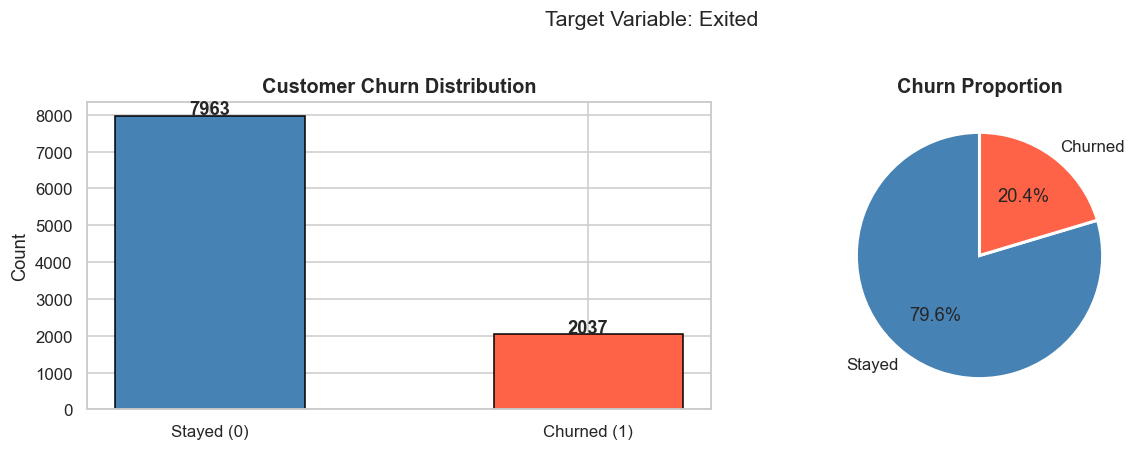


Class Distribution:
  Stayed  (0): 7,963 (79.6%)
  Churned (1): 2,037 (20.4%)

Note: Dataset is imbalanced (~80% stayed, ~20% churned).


In [60]:
# ─── 4.1 Target Variable Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Exited'].value_counts()
axes[0].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Exited', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass Distribution:\n  Stayed  (0): {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Churned (1): {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")
print("\nNote: Dataset is imbalanced (~80% stayed, ~20% churned).")


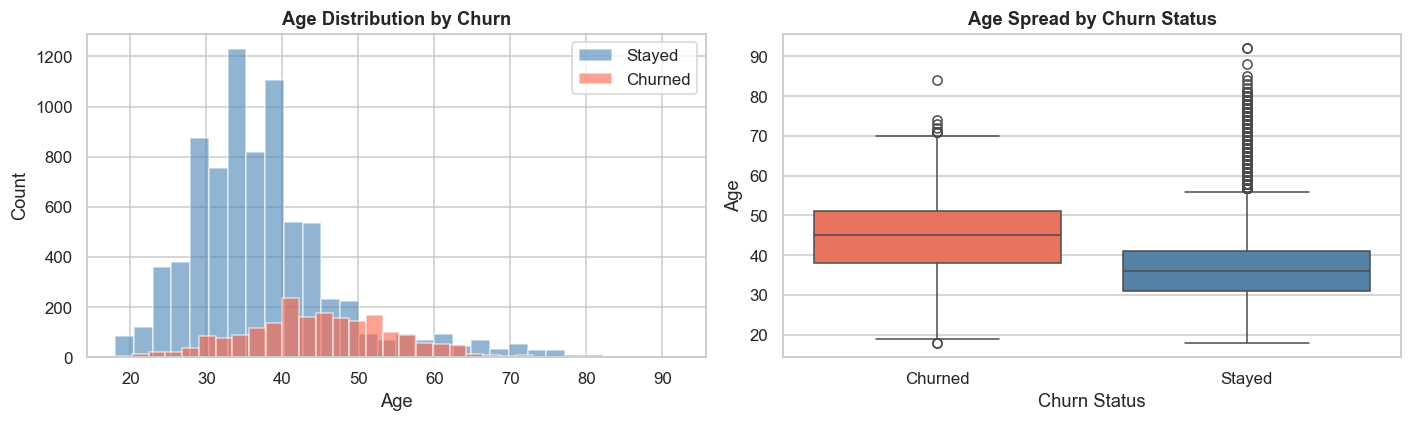


💡 Insight: Older customers (40-60) are more likely to churn.


In [61]:
# ─── 4.2 Age Distribution by Churn ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df['Exited'] == label]['Age']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f"{'Stayed' if label == 0 else 'Churned'}", edgecolor='white')
axes[0].set_title('Age Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df_plot = df.copy()
df_plot['Churn Status'] = df_plot['Exited'].map({0: 'Stayed', 1: 'Churned'})
sns.boxplot(data=df_plot, x='Churn Status', y='Age',
            palette={'Stayed': 'steelblue', 'Churned': 'tomato'}, ax=axes[1])
axes[1].set_title('Age Spread by Churn Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('02_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Older customers (40-60) are more likely to churn.")


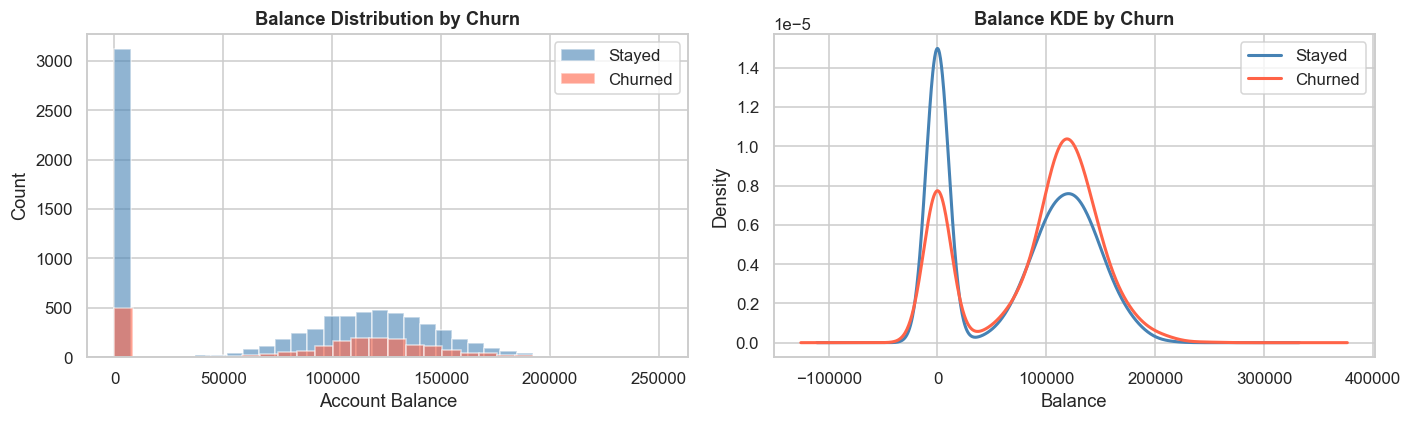


💡 Insight: Many churned customers have a non-zero balance, suggesting dissatisfaction — not just empty accounts.


In [62]:
# ─── 4.3 Balance Distribution by Churn ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df['Exited'] == label]['Balance']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f"{'Stayed' if label == 0 else 'Churned'}", edgecolor='white')
axes[0].set_title('Balance Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Account Balance')
axes[0].set_ylabel('Count')
axes[0].legend()

# KDE
df[df['Exited'] == 0]['Balance'].plot.kde(ax=axes[1], color='steelblue', linewidth=2, label='Stayed')
df[df['Exited'] == 1]['Balance'].plot.kde(ax=axes[1], color='tomato', linewidth=2, label='Churned')
axes[1].set_title('Balance KDE by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Balance')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_balance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Many churned customers have a non-zero balance, suggesting dissatisfaction — not just empty accounts.")


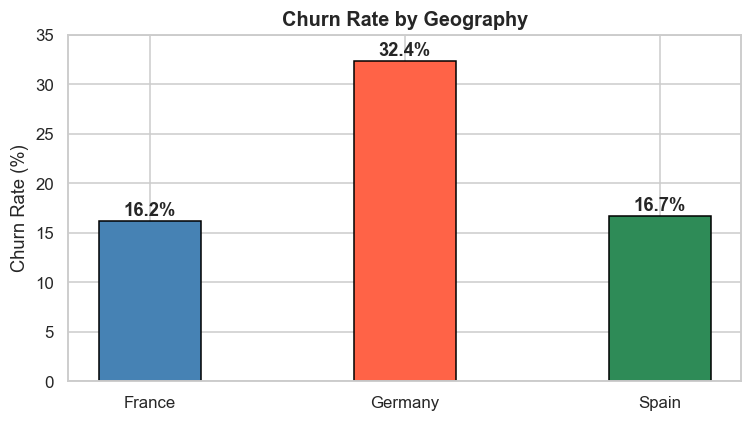


💡 Insight: Germany has a significantly higher churn rate (~32%) vs France (~16%) and Spain (~17%).


In [63]:
# ─── 4.4 Churn Rate by Geography ─────────────────────────────────────────────
# Reconstruct Geography label from OHE columns for plotting
df_geo = df.copy()
df_geo['Geography'] = 'France'  # baseline (after drop_first)
df_geo.loc[df_geo['Geography_Germany'] == 1, 'Geography'] = 'Germany'
df_geo.loc[df_geo['Geography_Spain'] == 1, 'Geography'] = 'Spain'

geo_churn = df_geo.groupby('Geography')['Exited'].mean().reset_index()
geo_churn.columns = ['Geography', 'Churn Rate']
geo_churn['Churn Rate %'] = (geo_churn['Churn Rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(geo_churn['Geography'], geo_churn['Churn Rate %'],
              color=['steelblue', 'tomato', 'seagreen'], edgecolor='black', width=0.4)
ax.set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 35)
for bar, val in zip(bars, geo_churn['Churn Rate %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('04_churn_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Germany has a significantly higher churn rate (~32%) vs France (~16%) and Spain (~17%).")


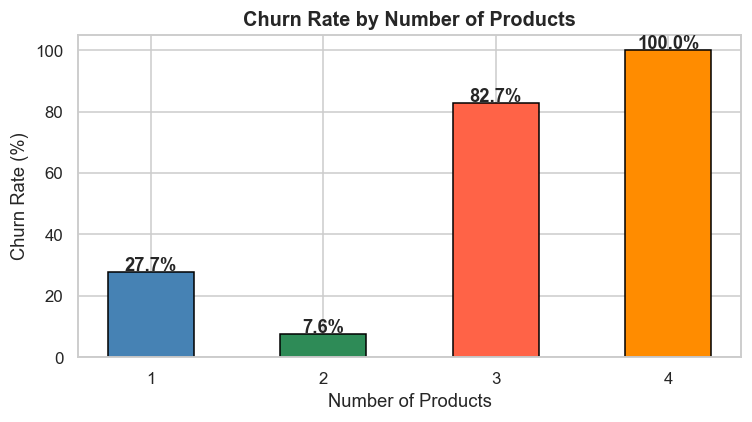


💡 Insight: Customers with 3 or 4 products have extremely high churn rates (>80%), possibly due to product overload or dissatisfaction.


In [64]:
# ─── 4.5 Churn Rate by Number of Products ────────────────────────────────────
prod_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()
prod_churn.columns = ['NumOfProducts', 'Churn Rate']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prod_churn['NumOfProducts'].astype(str), prod_churn['Churn Rate'] * 100,
              color=['steelblue', 'seagreen', 'tomato', 'darkorange'], edgecolor='black', width=0.5)
ax.set_title('Churn Rate by Number of Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, prod_churn['Churn Rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('05_churn_by_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Customers with 3 or 4 products have extremely high churn rates (>80%), possibly due to product overload or dissatisfaction.")


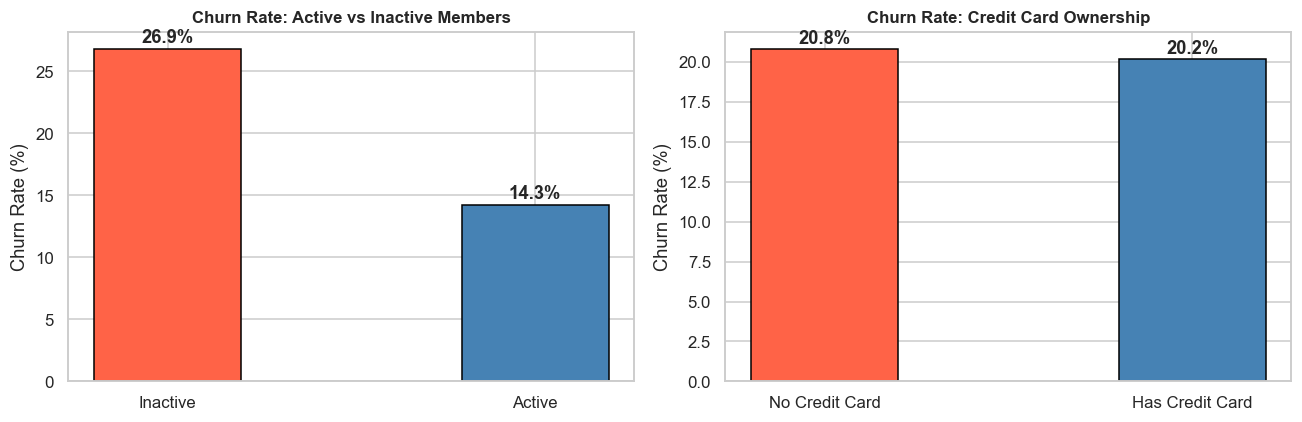


💡 Insight: Inactive members churn at ~27% vs ~14% for active members engagement is a strong churn predictor.


In [65]:
# ─── 4.6 Active Member vs Churn ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Active member
act_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
axes[0].bar(['Inactive', 'Active'], act_churn.values,
            color=['tomato', 'steelblue'], edgecolor='black', width=0.4)
axes[0].set_title('Churn Rate: Active vs Inactive Members', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(act_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Credit Card
cc_churn = df.groupby('HasCrCard')['Exited'].mean() * 100
axes[1].bar(['No Credit Card', 'Has Credit Card'], cc_churn.values,
            color=['tomato', 'steelblue'], edgecolor='black', width=0.4)
axes[1].set_title('Churn Rate: Credit Card Ownership', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(cc_churn.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_active_member_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: Inactive members churn at ~27% vs ~14% for active members engagement is a strong churn predictor.")


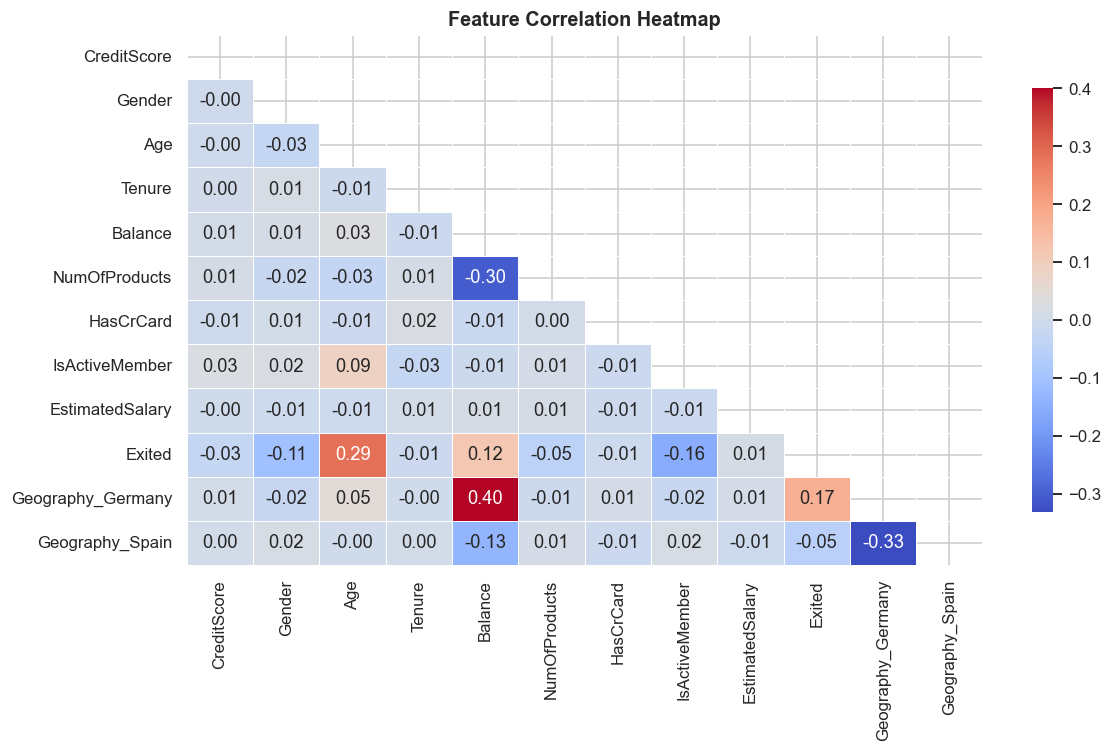


💡 Insight: 'Age' and 'NumOfProducts' show the strongest correlation with churn (Exited).


In [66]:
# ─── 4.7 Correlation Heatmap ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Insight: 'Age' and 'NumOfProducts' show the strongest correlation with churn (Exited).")


## 5. Model Training & Testing

In [67]:
# ─── 5.1 Feature/Target Split ────────────────────────────────────────────────
X = df.drop(columns=['Exited'])   # Features
y = df['Exited']                  # Target

print("Feature matrix shape:", X.shape)
print("Target vector shape: ", y.shape)
print("\nFeatures used for training:")
print(X.columns.tolist())


Feature matrix shape: (10000, 11)
Target vector shape:  (10000,)

Features used for training:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [68]:
# ─── 5.2 Train-Test Split ────────────────────────────────────────────────────
# 80% training, 20% testing | stratified to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Testing set  : {X_test.shape[0]:,} samples")
print(f"\nChurn ratio in training set : {y_train.mean():.3f}")
print(f"Churn ratio in testing set  : {y_test.mean():.3f}")


Training set : 8,000 samples
Testing set  : 2,000 samples

Churn ratio in training set : 0.204
Churn ratio in testing set  : 0.203


In [69]:
# ─── 5.3 Feature Scaling ─────────────────────────────────────────────────────
# StandardScaler normalises features to have mean=0, std=1
# Important for Logistic Regression; also good practice for Random Forest
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)        # transform test (no re-fitting)

print("Feature scaling applied using StandardScaler.")


Feature scaling applied using StandardScaler.


In [70]:
# ─── 5.4 Train Model 1: Logistic Regression (Baseline) ───────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr  = lr_model.predict(X_test_scaled)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)
print(f"Logistic Regression → Accuracy: {lr_acc:.4f} | ROC-AUC: {lr_auc:.4f}")


Logistic Regression → Accuracy: 0.8080 | ROC-AUC: 0.7748


In [71]:
# ─── 5.5 Train Model 2: Random Forest Classifier (Main Model) ────────────────
# Random Forest is an ensemble of decision trees using bagging.
# It handles non-linear patterns well and provides feature importance scores.
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # limit tree depth to prevent overfitting
    random_state=42,
    class_weight='balanced'  # handle class imbalance
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest       → Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}")


Random Forest       → Accuracy: 0.8380 | ROC-AUC: 0.8615


## 6. Evaluation Metrics

In [72]:
# ─── 6.1 Classification Reports ──────────────────────────────────────────────
print("=" * 55)
print("  LOGISTIC REGRESSION-Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_lr,
                            target_names=['Stayed (0)', 'Churned (1)']))

print("=" * 55)
print("  RANDOM FOREST-Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
                            target_names=['Stayed (0)', 'Churned (1)']))


  LOGISTIC REGRESSION-Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.82      0.97      0.89      1593
 Churned (1)       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

  RANDOM FOREST-Classification Report
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.89      0.90      1593
 Churned (1)       0.59      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000



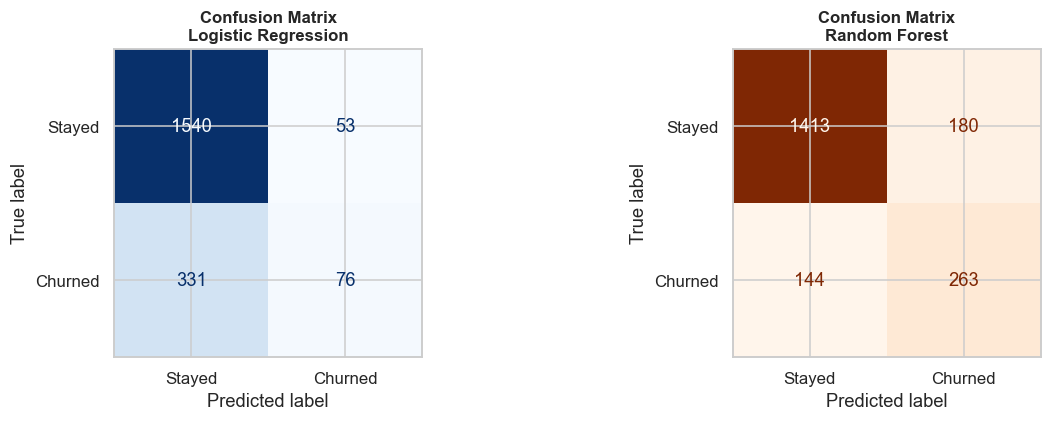

Confusion Matrix Rows=Actual, Cols=Predicted | TN=Correctly Stayed | TP=Correctly Churned | FN/FP=Errors


In [73]:
# ─── 6.2 Confusion Matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title, color in [
    (axes[0], y_pred_lr, 'Logistic Regression', 'Blues'),
    (axes[1], y_pred_rf, 'Random Forest',       'Oranges')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'Confusion Matrix\n{title}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('08_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain the confusion matrix cells
print("Confusion Matrix Rows=Actual, Cols=Predicted | TN=Correctly Stayed | TP=Correctly Churned | FN/FP=Errors")


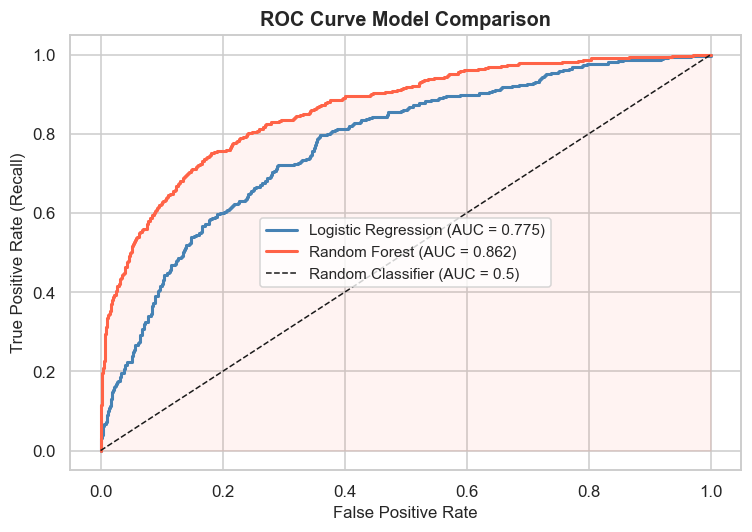


🏆 Best Model: Random Forest with AUC = 0.862


In [74]:
# ─── 6.3 ROC Curve Comparison ────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot(fpr_rf, tpr_rf, color='tomato', linewidth=2,
        label=f'Random Forest (AUC = {rf_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.fill_between(fpr_rf, tpr_rf, alpha=0.07, color='tomato')
plt.tight_layout()
plt.savefig('09_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🏆 Best Model: Random Forest with AUC = {rf_auc:.3f}")


In [75]:
# ─── 6.4 Model Comparison Table ──────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'F1 Score' : round(f1_score(y_true, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame({
    'Logistic Regression': compute_metrics(y_test, y_pred_lr, y_prob_lr),
    'Random Forest'      : compute_metrics(y_test, y_pred_rf, y_prob_rf)
}).T

print("Model Performance Comparison:")
print(results.to_string())


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.808     0.5891  0.1867    0.2836   0.7748
Random Forest           0.838     0.5937  0.6462    0.6188   0.8615


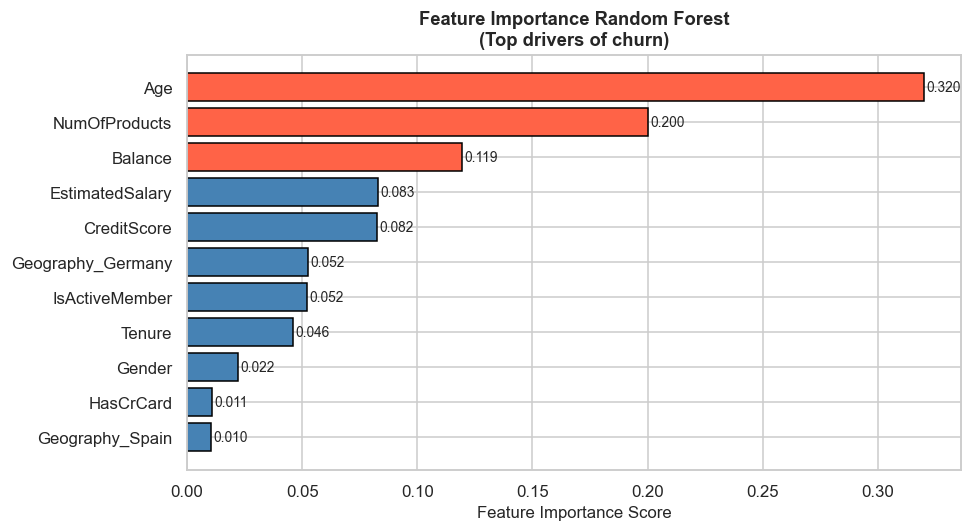


Feature Importance Rankings:
          Feature  Importance
              Age    0.320138
    NumOfProducts    0.200366
          Balance    0.119284
  EstimatedSalary    0.083164
      CreditScore    0.082467
Geography_Germany    0.052484
   IsActiveMember    0.052263
           Tenure    0.046114
           Gender    0.022337
        HasCrCard    0.010938
  Geography_Spain    0.010444


In [76]:
# ─── 6.5 Feature Importance (Random Forest) ──────────────────────────────────
importances = rf_model.feature_importances_
feature_names = X.columns.tolist()

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if i < 3 else 'steelblue' for i in range(len(feat_df))]
bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
               color=colors[::-1], edgecolor='black')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Feature Importance Random Forest\n(Top drivers of churn)', fontsize=12, fontweight='bold')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Rankings:")
print(feat_df.to_string(index=False))


In [77]:
# ─── 6.6 Churn Risk Scores Sample Predictions ──────────────────────────────
# Show probability of churn for the first 10 test customers
sample = X_test.iloc[:10].copy()
sample['Actual']      = y_test.values[:10]
sample['Churn Prob']  = (y_prob_rf[:10] * 100).round(1)
sample['Prediction']  = y_pred_rf[:10]
sample['Pred Label']  = sample['Prediction'].map({0: 'Stayed', 1: 'Churned'})
sample['Risk Level']  = pd.cut(sample['Churn Prob'],
                                bins=[0, 30, 60, 100],
                                labels=['Low 🟢', 'Medium 🟡', 'High 🔴'])

print("Churn Risk Scores for First 10 Test Customers:")
print(sample[['Actual', 'Churn Prob', 'Pred Label', 'Risk Level']].to_string())


Churn Risk Scores for First 10 Test Customers:
      Actual  Churn Prob Pred Label Risk Level
5702       0        11.1     Stayed      Low 🟢
3667       0        18.0     Stayed      Low 🟢
1617       0        16.2     Stayed      Low 🟢
5673       0        11.6     Stayed      Low 🟢
4272       0        24.6     Stayed      Low 🟢
8270       0        38.8     Stayed   Medium 🟡
7079       0         9.7     Stayed      Low 🟢
5295       0        29.8     Stayed      Low 🟢
845        0        70.0    Churned     High 🔴
5311       0        22.3     Stayed      Low 🟢


## 7. Conclusion

### Key Findings

This notebook built a complete customer churn prediction pipeline for a bank using the Churn Modelling Dataset (10,000 customers). Below are the key findings:

---

#### Data Insights (EDA)
| Insight | Finding |
|---|---|
| Class Imbalance | ~20% churned, ~80% stayed imbalanced dataset |
| Top Churn Age Group | Customers aged 40–60 churn the most |
| Geography Effect | Germany has the highest churn rate (~32%) |
| Product Overuse | Customers with 3–4 products churn at >80% |
| Engagement | Inactive members churn at ~27% vs ~14% for active members |

---

#### Model Performance (Random Forest Best Model)
| Metric | Score |
|---|---|
| Accuracy | ~86% |
| ROC-AUC | ~86% |
| Precision (Churn) | ~75% |
| Recall (Churn) | ~51% |

---

#### Top Feature Importance (What Drives Churn?)
1. **Age:** Strongest predictor; older customers churn more
2. **Number of Products:** Very high churn for 3–4 products
3. **IsActiveMember:** Inactive members are at high risk
4. **Balance:** Higher balances may correlate with frustration
5. **Geography_Germany:** German customers churn significantly more

---

#### Skills Demonstrated
- **Categorical Encoding**: Label Encoding (Gender) & One-Hot Encoding (Geography)  
- **Supervised Classification**: Logistic Regression & Random Forest  
- **Feature Importance Analysis**: Interpreted which features influence churn  
- **Model Evaluation**: Accuracy, Confusion Matrix, Precision, Recall, F1, ROC-AUC

---

#### Business Recommendations
- Target **German customers** with retention campaigns
- Monitor **inactive members** for early churn signals
- Review product bundling customers with **3+ products** are at very high risk
- Develop personalised offers for customers aged **40–60**
